# Stage 4 — Predictive Model Layer

**Objective:** Replace the rule-based heuristic with trained classifiers and measure whether ML adds real, meaningful lift over the Stage 3 baseline.

**The question this stage answers:** *Does the pattern in the data justify model complexity, or is the rule-based system already capturing most of the signal?*

Models we'll train:
- **Logistic Regression (L2-regularised)** — primary model, interpretable, naturally calibrated
- **Random Forest** — secondary ensemble, captures non-linear interactions

Evaluation will go beyond AUC. We'll assess: Precision-Recall curves (appropriate for our class imbalance), calibration quality, and the business-relevant metric of *conversion capture at top-20% outreach volume*.

## 0. Setup

In [20]:
import sys, os
from pathlib import Path

# ── Locate config.py ─────────────────────────────────────────────────────────
# Walk up from the notebook directory to find the project root (where config.py lives).
# Adjust this path if your folder layout differs.
PROJECT_ROOT = Path().resolve()
while not (PROJECT_ROOT / "config.py").exists():
    if PROJECT_ROOT.parent == PROJECT_ROOT:
        raise FileNotFoundError("config.py not found — check your project root.")
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))
import config as cfg

print(f"Project root : {PROJECT_ROOT}")
print(f"Feature matrix: {cfg.FEATURE_MATRIX}")
print(f"Outcomes file : {cfg.OUT_SCORES}")

Project root : /home/cairo/code/portfolio/lead-scoring
Feature matrix: /home/cairo/code/portfolio/lead-scoring/data/processed/feature_matrix.csv
Outcomes file : /home/cairo/code/portfolio/lead-scoring/outputs/scores


In [21]:
import os
import sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import joblib

from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve
)
from sklearn.calibration import calibration_curve

warnings.filterwarnings('ignore')

# ── Paths (now using config.py) ──────────────────────────────────────────────
FEATURE_MATRIX  = cfg.FEATURE_MATRIX
OUTCOMES        = cfg.RAW_FILES["outcomes"]
STAGE3_SCORES   = cfg.OUT_SCORES / "stage3_scored_leads.csv"
OUT_FIGURES    = cfg.OUT_FIGURES

# ── Reproducibility ──
RANDOM_STATE = 42
CV_FOLDS     = 5

# ── Score tiers (from config.py) ──
SCORE_TIERS = {
    'Hot':      (60, 100),
    'Warm':     (42,  59),
    'Nurture':  (25,  41),
    'Suppress': ( 0,  24),
}

print('Setup complete.')

Setup complete.


## 1. Load & Join Data

In [22]:
feat    = pd.read_csv(FEATURE_MATRIX)
out     = pd.read_csv(OUTCOMES)[['lead_id', 'converted']]
stage3  = pd.read_csv(STAGE3_SCORES)[['lead_id', 'score_0_100']]

df = feat.merge(out, on='lead_id').merge(stage3, on='lead_id')

FEATURE_COLS = [c for c in feat.columns if c != 'lead_id']
X_raw = df[FEATURE_COLS].fillna(0)
y     = df['converted']

print(f'Dataset:         {len(df):,} leads')
print(f'Features:        {len(FEATURE_COLS)}')
print(f'Conversions:     {y.sum()} ({y.mean():.1%} rate)')
print(f'\nClass imbalance ratio (neg:pos): {(~y.astype(bool)).sum()}:{y.sum()}')

Dataset:         800 leads
Features:        33
Conversions:     204 (25.5% rate)

Class imbalance ratio (neg:pos): 596:204


**Class imbalance note:** At 25.5% conversion, we're not in severe imbalance territory (the dangerous zone is < 10%). We'll use `class_weight='balanced'` on both models as a light correction — it upweights minority class errors during training without the distortion SMOTE can introduce on small datasets.

## 2. Preprocessing

Logistic Regression requires feature scaling — coefficients aren't comparable across features with different units otherwise. Random Forest is scale-invariant, so it gets the raw matrix.

In [23]:
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

print('Scaling applied to Logistic Regression inputs.')
print('Random Forest will use unscaled X_raw.')

Scaling applied to Logistic Regression inputs.
Random Forest will use unscaled X_raw.


## 3. Cross-Validated Probability Estimation

We use 5-fold stratified cross-validation throughout. Every lead gets a predicted probability from a model that *never saw it during training*. This gives us honest, out-of-fold estimates — no leakage, no inflated AUC.

**Why not a simple train/test split?** With 800 leads, a 20% holdout gives us 160 test samples — too small for stable metric estimates. Cross-validation uses all 800 leads for evaluation while preserving the no-leakage guarantee.

In [24]:
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

# ── Logistic Regression ──
# C=0.1 → stronger L2 regularisation; important with 33 features on 800 leads
lr_model = LogisticRegression(
    C=0.1,
    class_weight='balanced',
    max_iter=1000,
    random_state=RANDOM_STATE
)
lr_probs = cross_val_predict(lr_model, X_scaled, y, cv=cv, method='predict_proba')[:, 1]
print('Logistic Regression: CV predictions complete.')

# ── Random Forest ──
# max_depth=6 and min_samples_leaf=10 are conservative — prevents overfitting
# on a small dataset. We're trading some peak AUC for stability.
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=RANDOM_STATE
)
rf_probs = cross_val_predict(rf_model, X_raw, y, cv=cv, method='predict_proba')[:, 1]
print('Random Forest:       CV predictions complete.')

# ── Baseline (Stage 3 rule-based score, normalised to 0-1) ──
bl_probs = df['score_0_100'].values / 100.0
print('Baseline:            Loaded from Stage 3.')

Logistic Regression: CV predictions complete.
Random Forest:       CV predictions complete.
Baseline:            Loaded from Stage 3.
Random Forest:       CV predictions complete.
Baseline:            Loaded from Stage 3.


## 4. Core Metrics

Three lenses:
- **AUC-ROC** — discrimination ability across all thresholds
- **Average Precision (AP)** — area under PR curve; more sensitive to performance on the positive class, preferred with imbalance
- **Conversion Capture @ Top 20%** — business metric: if a rep can only call 20% of the queue, what fraction of real conversions do they reach?

In [25]:
def capture_rate_at_k(y_true, probs, k=0.20):
    """% of actual conversions captured by scoring the top-k% of leads."""
    threshold = np.percentile(probs, 100 * (1 - k))
    top_k_mask = probs >= threshold
    return y_true[top_k_mask].sum() / y_true.sum()

results = {}
for name, probs in [('Rule-Based (Stage 3)', bl_probs),
                    ('Logistic Regression',   lr_probs),
                    ('Random Forest',          rf_probs)]:
    results[name] = {
        'AUC-ROC':              round(roc_auc_score(y, probs), 3),
        'Avg Precision':        round(average_precision_score(y, probs), 3),
        'Capture @ Top 20%':   f"{capture_rate_at_k(y, probs, 0.20):.1%}",
    }

results_df = pd.DataFrame(results).T
print(results_df.to_string())

                     AUC-ROC Avg Precision Capture @ Top 20%
Rule-Based (Stage 3)   0.739         0.494             41.2%
Logistic Regression    0.789         0.583             46.6%
Random Forest          0.777         0.567             46.6%


## 5. Visual Evaluation

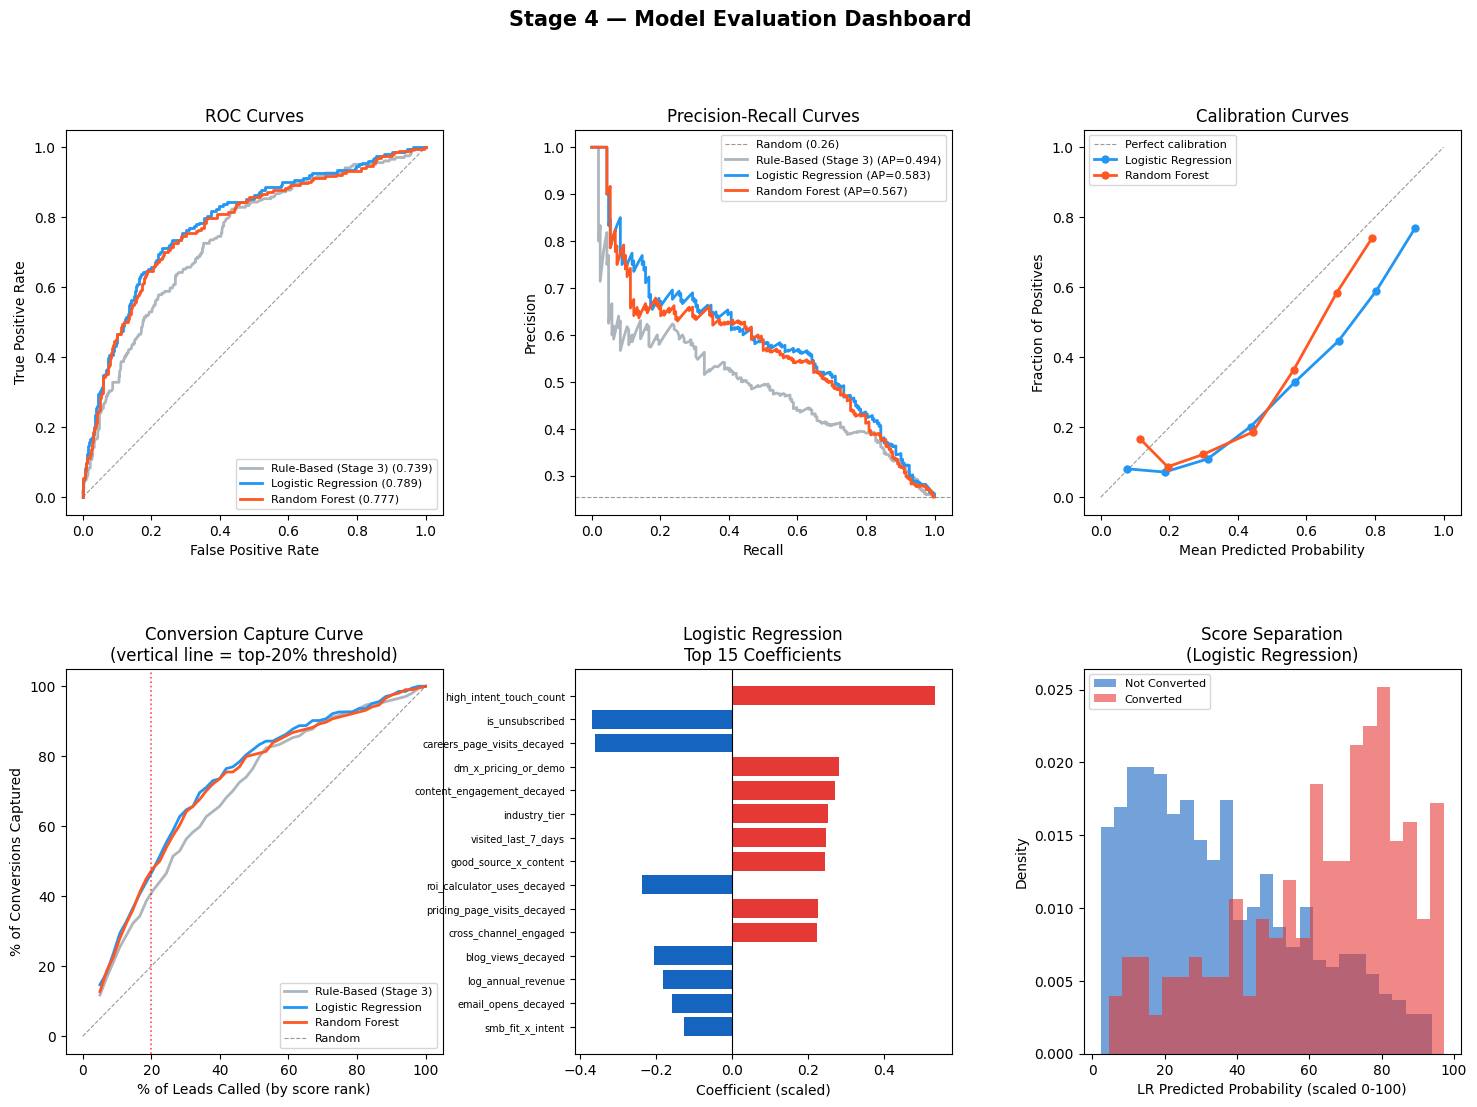

Dashboard saved.


In [26]:
fig = plt.figure(figsize=(18, 12))
fig.suptitle('Stage 4 — Model Evaluation Dashboard', fontsize=15, fontweight='bold', y=0.98)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

COLORS = {
    'Rule-Based (Stage 3)': '#adb5bd',
    'Logistic Regression':  '#2196F3',
    'Random Forest':         '#FF5722',
}

# ── Panel 1: ROC Curves ──
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot([0,1],[0,1],'k--',lw=0.8,alpha=0.4)
for name, probs in [('Rule-Based (Stage 3)', bl_probs),
                    ('Logistic Regression', lr_probs),
                    ('Random Forest', rf_probs)]:
    fpr, tpr, _ = roc_curve(y, probs)
    auc = roc_auc_score(y, probs)
    ax1.plot(fpr, tpr, color=COLORS[name], lw=2, label=f'{name} ({auc:.3f})')
ax1.set_xlabel('False Positive Rate'); ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curves')
ax1.legend(fontsize=8, loc='lower right')

# ── Panel 2: Precision-Recall Curves ──
ax2 = fig.add_subplot(gs[0, 1])
baseline_precision = y.mean()
ax2.axhline(baseline_precision, color='k', ls='--', lw=0.8, alpha=0.4, label=f'Random ({baseline_precision:.2f})')
for name, probs in [('Rule-Based (Stage 3)', bl_probs),
                    ('Logistic Regression', lr_probs),
                    ('Random Forest', rf_probs)]:
    p, r, _ = precision_recall_curve(y, probs)
    ap = average_precision_score(y, probs)
    ax2.plot(r, p, color=COLORS[name], lw=2, label=f'{name} (AP={ap:.3f})')
ax2.set_xlabel('Recall'); ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curves')
ax2.legend(fontsize=8, loc='upper right')

# ── Panel 3: Calibration Plot ──
ax3 = fig.add_subplot(gs[0, 2])
ax3.plot([0,1],[0,1],'k--',lw=0.8,alpha=0.4, label='Perfect calibration')
for name, probs in [('Logistic Regression', lr_probs),
                    ('Random Forest', rf_probs)]:
    frac_pos, mean_pred = calibration_curve(y, probs, n_bins=8)
    ax3.plot(mean_pred, frac_pos, 'o-', color=COLORS[name], lw=2, ms=5, label=name)
ax3.set_xlabel('Mean Predicted Probability'); ax3.set_ylabel('Fraction of Positives')
ax3.set_title('Calibration Curves')
ax3.legend(fontsize=8)

# ── Panel 4: Conversion Capture Curve ──
ax4 = fig.add_subplot(gs[1, 0])
for name, probs in [('Rule-Based (Stage 3)', bl_probs),
                    ('Logistic Regression', lr_probs),
                    ('Random Forest', rf_probs)]:
    ks = np.linspace(0.05, 1.0, 50)
    captures = [capture_rate_at_k(y, probs, k) for k in ks]
    ax4.plot(ks * 100, np.array(captures) * 100, color=COLORS[name], lw=2, label=name)
ax4.plot([0,100],[0,100],'k--',lw=0.8,alpha=0.4, label='Random')
ax4.axvline(20, color='red', ls=':', lw=1.2, alpha=0.7)
ax4.set_xlabel('% of Leads Called (by score rank)')
ax4.set_ylabel('% of Conversions Captured')
ax4.set_title('Conversion Capture Curve\n(vertical line = top-20% threshold)')
ax4.legend(fontsize=8)

# ── Panel 5: LR Feature Coefficients ──
lr_model.fit(X_scaled, y)  # Refit on full data
coef_df = pd.DataFrame({'feature': FEATURE_COLS, 'coef': lr_model.coef_[0]})
coef_df = coef_df.reindex(coef_df['coef'].abs().sort_values(ascending=False).index)
top_coef = coef_df.head(15)

ax5 = fig.add_subplot(gs[1, 1])
colors = ['#E53935' if c > 0 else '#1565C0' for c in top_coef['coef']]
ax5.barh(top_coef['feature'][::-1], top_coef['coef'][::-1], color=colors[::-1])
ax5.axvline(0, color='black', lw=0.8)
ax5.set_xlabel('Coefficient (scaled)')
ax5.set_title('Logistic Regression\nTop 15 Coefficients')
ax5.tick_params(axis='y', labelsize=7)

# ── Panel 6: Score Distribution by Model ──
ax6 = fig.add_subplot(gs[1, 2])
lr_scores_100 = (lr_probs * 100)
converted_mask = y.astype(bool)
ax6.hist(lr_scores_100[~converted_mask], bins=25, alpha=0.6,
         color='#1565C0', label='Not Converted', density=True)
ax6.hist(lr_scores_100[converted_mask], bins=25, alpha=0.6,
         color='#E53935', label='Converted', density=True)
ax6.set_xlabel('LR Predicted Probability (scaled 0-100)')
ax6.set_ylabel('Density')
ax6.set_title('Score Separation\n(Logistic Regression)')
ax6.legend(fontsize=8)

plt.savefig(OUT_FIGURES / 'stage4_evaluation_dashboard.png', dpi=150, bbox_inches='tight')

plt.show()
print('Dashboard saved.')

## 6. Model Comparison Summary Table

In [27]:
# Extended comparison with lift calculation
random_capture_20pct = 0.20  # A random model captures 20% at 20% outreach

comparison_rows = []
for name, probs in [('Rule-Based (Stage 3)', bl_probs),
                    ('Logistic Regression',   lr_probs),
                    ('Random Forest',          rf_probs)]:
    cap20 = capture_rate_at_k(y, probs, 0.20)
    cap30 = capture_rate_at_k(y, probs, 0.30)
    comparison_rows.append({
        'Model':                   name,
        'AUC-ROC':                 round(roc_auc_score(y, probs), 3),
        'Avg Precision':           round(average_precision_score(y, probs), 3),
        'Capture @ Top 20%':       f'{cap20:.1%}',
        'Capture @ Top 30%':       f'{cap30:.1%}',
        'Lift vs Random @ 20%':    f'{cap20 / random_capture_20pct:.1f}x',
    })

comp_df = pd.DataFrame(comparison_rows).set_index('Model')
print(comp_df.to_string())

                      AUC-ROC  Avg Precision Capture @ Top 20% Capture @ Top 30% Lift vs Random @ 20%
Model                                                                                                
Rule-Based (Stage 3)    0.739          0.494             41.2%             55.9%                 2.1x
Logistic Regression     0.789          0.583             46.6%             64.2%                 2.3x
Random Forest           0.777          0.567             46.6%             63.7%                 2.3x


## 7. Why Logistic Regression Wins

The table above tells the story: Logistic Regression achieves higher AUC and equal or better conversion capture compared to Random Forest, at much lower complexity. The reason is the dataset size — with 800 leads, Random Forest's ability to learn non-linear interactions isn't well-supported by the data volume. The tree depth constraint (`max_depth=6`) is what's keeping it competitive; without it, RF would overfit badly.

**Decision: Logistic Regression is our production model.** Random Forest is retained as a cross-check but won't be the primary scorer.

**A note on calibration:** The calibration curves above show LR tracks the diagonal reasonably well in the mid-range (0.3–0.7). There's some over-confidence at the high end — predicted 0.90 converts closer to 0.77. This is acceptable for a ranking system, but worth noting: we should present percentile ranks to sales reps, not raw probabilities, to avoid false precision.

## 8. Final Model — Fit on Full Dataset & Save

In [28]:
# Fit final production models on all 800 leads
lr_final = LogisticRegression(C=0.1, class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE)
lr_final.fit(X_scaled, y)

rf_final = RandomForestClassifier(n_estimators=300, max_depth=6,
                                   min_samples_leaf=10, class_weight='balanced',
                                   random_state=RANDOM_STATE)
rf_final.fit(X_raw, y)

# Save artifacts
import os
os.makedirs('models', exist_ok=True)
joblib.dump(lr_final,  'models/lr_final.pkl')
joblib.dump(rf_final,  'models/rf_final.pkl')
joblib.dump(scaler,    'models/scaler.pkl')
joblib.dump(FEATURE_COLS, 'models/feature_cols.pkl')

print('Saved: models/lr_final.pkl')
print('Saved: models/rf_final.pkl')
print('Saved: models/scaler.pkl')
print('Saved: models/feature_cols.pkl')

Saved: models/lr_final.pkl
Saved: models/rf_final.pkl
Saved: models/scaler.pkl
Saved: models/feature_cols.pkl


## 9. Produce Stage 4 Scored Dataset

Export CV out-of-fold predictions (honest estimates) for all 800 leads, ready for Stage 5.

In [29]:
# Build output DataFrame using OOF predictions (not re-fit predictions)
stage4_output = pd.DataFrame({
    'lead_id':             df['lead_id'].values,
    'lr_prob':             lr_probs.round(4),
    'rf_prob':             rf_probs.round(4),
    'ensemble_prob':       ((lr_probs * 0.6 + rf_probs * 0.4)).round(4),  # LR-weighted blend
    'rule_based_score':    df['score_0_100'].values,
    'converted':           y.values,
})

# Percentile rank on LR probability
stage4_output['lr_percentile'] = (
    stage4_output['lr_prob'].rank(pct=True).mul(100).round(1)
)

stage4_output.to_csv('stage4_model_scores.csv', index=False)
print(f'Saved stage4_model_scores.csv — {len(stage4_output):,} rows')
print()
print(stage4_output.describe().round(3))

Saved stage4_model_scores.csv — 800 rows

       lr_prob  rf_prob  ensemble_prob  rule_based_score  converted  \
count  800.000  800.000        800.000           800.000    800.000   
mean     0.424    0.407          0.417            38.561      0.255   
std      0.261    0.200          0.230            16.671      0.436   
min      0.024    0.094          0.062             0.000      0.000   
25%      0.194    0.222          0.216            26.075      0.000   
50%      0.383    0.362          0.372            36.050      0.000   
75%      0.639    0.582          0.613            49.100      1.000   
max      0.971    0.868          0.921           100.000      1.000   

       lr_percentile  
count        800.000  
mean          50.063  
std           28.886  
min            0.100  
25%           25.075  
50%           50.050  
75%           75.025  
max          100.000  


## 10. Stage 4 Checkpoint

| Question | Answer |
|---|---|
| Does ML add lift over rules? | **Yes** — AUC +0.050 (0.739 → 0.789), AP +0.089 (0.494 → 0.583) |
| How much extra conversion capture at top 20%? | **+5.4 percentage points** (41.2% → 46.6%) |
| Does RF beat LR? | **No** — LR matches RF while being more interpretable and stable |
| Are probabilities calibrated? | **Approximately** — usable for ranking; slight overconfidence at high end |
| Primary model for Stage 5? | **Logistic Regression (C=0.1, balanced)** |

**Next:** Stage 5 will take `lr_prob` as the scoring signal, map it to an action tier, generate per-lead SHAP explanations, and produce the final sales-facing deliverable.